Libraryes

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

data set

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/insurance.csv")

print(df.head())
print(df.shape)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)


data cleaning

In [3]:
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

print("Duplicates Removed")
print(df.shape)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicates Removed
(1337, 7)


distriputive statices

In [4]:
print("Average Charges :", df['charges'].mean())
print("Average Age :", df['age'].mean())
print("Average BMI :", df['bmi'].mean())
print("Average Children :", df['children'].mean())

print(df.describe())

Average Charges : 13279.121486655948
Average Age : 39.222139117427076
Average BMI : 30.66345175766642
Average Children : 1.0957367240089753
               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


encode

In [5]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

viasulazation

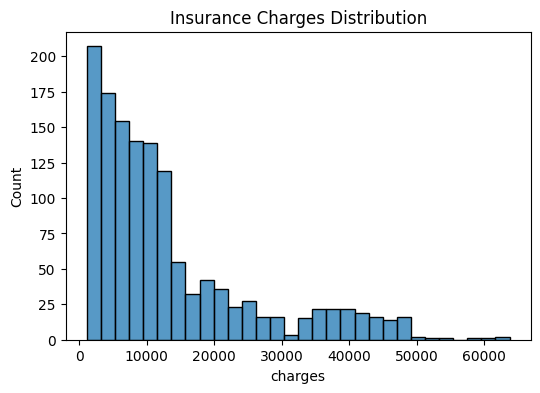

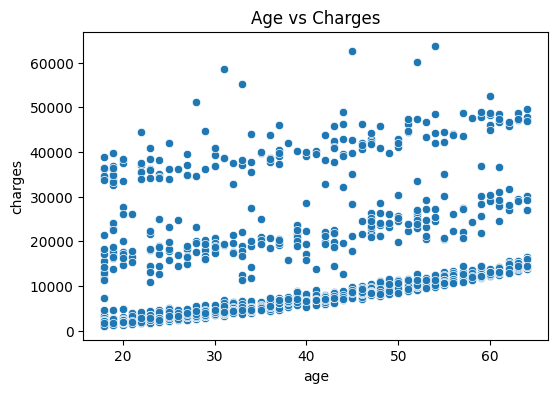

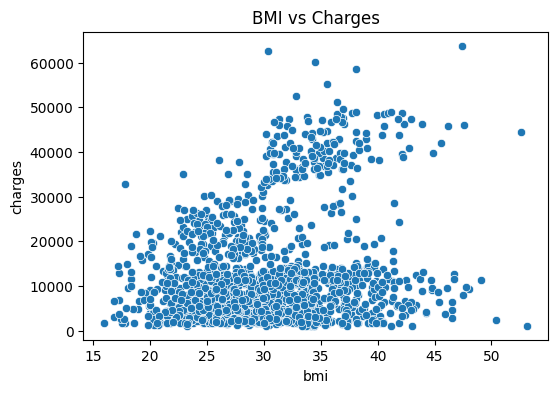

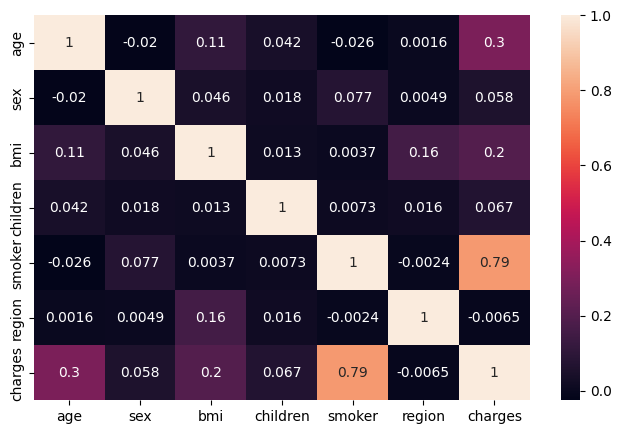

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['charges'], bins=30)
plt.title("Insurance Charges Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True)
plt.show()


Risk analyze

In [7]:
def risk_category(charge):

    if charge < 10000:
        return "Low Cost"

    elif charge < 30000:
        return "Medium Cost"

    else:
        return "High Cost"

df["Risk_Category"] = df["charges"].apply(risk_category)

print(df["Risk_Category"].value_counts())

Risk_Category
Low Cost       711
Medium Cost    464
High Cost      162
Name: count, dtype: int64


simple linear regersion

In [8]:

X = df[['age']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("\nSIMPLE LINEAR REGRESSION")

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))


SIMPLE LINEAR REGRESSION
R2 Score : 0.09513000782072023
MAE : 9657.78934976123
MSE : 166275348.23176482
RMSE : 12894.779883028823


multiple linear regresion

In [9]:
X = df[['age', 'bmi', 'children', 'smoker']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

mlr = LinearRegression()

mlr.fit(X_train, y_train)

y_pred = mlr.predict(X_test)

print("\nMULTIPLE LINEAR REGRESSION")

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))


MULTIPLE LINEAR REGRESSION
R2 Score : 0.8045531086669288
MAE : 4198.592612356366
MSE : 35914551.48043363
RMSE : 5992.875059638206


logistice regresion

In [10]:
median_charge = df['charges'].median()

df['insurance_category'] = np.where(
    df['charges'] >= median_charge,
    1,
    0
)

X = df[['age', 'bmi', 'children', 'smoker']]
y = df['insurance_category']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("\nLOGISTIC REGRESSION")

print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :",
      precision_score(y_test, y_pred))

print("Recall :",
      recall_score(y_test, y_pred))

print("F1 Score :",
      f1_score(y_test, y_pred))

print("\nConfusion Matrix")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")

print(classification_report(y_test, y_pred))



LOGISTIC REGRESSION
Accuracy : 0.8992537313432836
Precision : 0.8811188811188811
Recall : 0.9264705882352942
F1 Score : 0.9032258064516129

Confusion Matrix
[[115  17]
 [ 10 126]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       132
           1       0.88      0.93      0.90       136

    accuracy                           0.90       268
   macro avg       0.90      0.90      0.90       268
weighted avg       0.90      0.90      0.90       268



daseboard

In [15]:
# Install Streamlit if not already installed
!pip install streamlit

import streamlit as st
import pandas as pd
import plotly.express as px

# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/insurance.csv")

st.set_page_config(
    page_title="Medical Insurance Dashboard",
    layout="wide"
)

st.title("🏥 Medical Insurance Cost Analysis Dashboard")

# ==========================
# SIDEBAR FILTERS
# ==========================

st.sidebar.header("Filters")

gender = st.sidebar.multiselect(
    "Select Gender",
    df["sex"].unique(),
    default=df["sex"].unique()
)

region = st.sidebar.multiselect(
    "Select Region",
    df["region"].unique(),
    default=df["region"].unique()
)

smoker = st.sidebar.multiselect(
    "Select Smoker Status",
    df["smoker"].unique(),
    default=df["smoker"].unique()
)

children = st.sidebar.slider(
    "Number of Children",
    int(df["children"].min()),
    int(df["children"].max()),
    (
        int(df["children"].min()),
        int(df["children"].max())
    )
)

age = st.sidebar.slider(
    "Age",
    int(df["age"].min()),
    int(df["age"].max()),
    (
        int(df["age"].min()),
        int(df["age"].max())
    )
)

# ==========================
# FILTER DATA
# ==========================

filtered_df = df[
    (df["sex"].isin(gender)) &
    (df["region"].isin(region)) &
    (df["smoker"].isin(smoker)) &
    (df["children"] >= children[0]) &
    (df["children"] <= children[1]) &
    (df["age"] >= age[0]) &
    (df["age"] <= age[1])
]

# ==========================
# KPI CARDS
# ==========================

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Total Customers",
    len(filtered_df)
)

col2.metric(
    "Average Charges",
    f"${filtered_df['charges'].mean():,.2f}"
)

col3.metric(
    "Average BMI",
    round(filtered_df["bmi"].mean(), 2)
)

col4.metric(
    "Average Age",
    round(filtered_df["age"].mean(), 2)
)

# ==========================
# CHARGES DISTRIBUTION
# ==========================

st.subheader("Insurance Charges Distribution")

fig1 = px.histogram(
    filtered_df,
    x="charges",
    nbins=30,
    title="Charges Distribution"
)

st.plotly_chart(fig1, use_container_width=True)

# ==========================
# AGE VS CHARGES
# ==========================

st.subheader("Age vs Charges")

fig2 = px.scatter(
    filtered_df,
    x="age",
    y="charges",
    color="smoker",
    hover_data=["sex", "region"]
)

st.plotly_chart(fig2, use_container_width=True)

# ==========================
# BMI VS CHARGES
# ==========================

st.subheader("BMI vs Charges")

fig3 = px.scatter(
    filtered_df,
    x="bmi",
    y="charges",
    color="smoker"
)

st.plotly_chart(fig3, use_container_width=True)

# ==========================
# SMOKER VS NON-SMOKER
# ==========================

st.subheader("Smoker vs Non-Smoker Charges")

fig4 = px.box(
    filtered_df,
    x="smoker",
    y="charges",
    color="smoker"
)

st.plotly_chart(fig4, use_container_width=True)

# ==========================
# REGION WISE CHARGES
# ==========================

st.subheader("Region-wise Charges")

region_data = (
    filtered_df
    .groupby("region")["charges"]
    .mean()
    .reset_index()
)

fig5 = px.bar(
    region_data,
    x="region",
    y="charges"
)

st.plotly_chart(fig5, use_container_width=True)

# ==========================
# GENDER WISE CHARGES
# ==========================

st.subheader("Gender-wise Charges")

gender_data = (
    filtered_df
    .groupby("sex")["charges"]
    .mean()
    .reset_index()
)

fig6 = px.bar(
    gender_data,
    x="sex",
    y="charges",
    color="sex"
)

st.plotly_chart(fig6, use_container_width=True)

# ==========================
# PIE CHARTS
# ==========================

col1, col2 = st.columns(2)

with col1:

    smoker_count = (
        filtered_df["smoker"]
        .value_counts()
        .reset_index()
    )

    smoker_count.columns = [
        "Smoker",
        "Count"
    ]

    fig7 = px.pie(
        smoker_count,
        names="Smoker",
        values="Count",
        title="Smoker Distribution"
    )

    st.plotly_chart(
        fig7,
        use_container_width=True
    )

with col2:

    gender_count = (
        filtered_df["sex"]
        .value_counts()
        .reset_index()
    )

    gender_count.columns = [
        "Gender",
        "Count"
    ]

    fig8 = px.pie(
        gender_count,
        names="Gender",
        values="Count",
        title="Gender Distribution"
    )

    st.plotly_chart(
        fig8,
        use_container_width=True
    )

# ==========================
# CORRELATION HEATMAP
# ==========================

st.subheader("Correlation Heatmap")

corr = filtered_df.select_dtypes(
    include="number"
).corr()

fig9 = px.imshow(
    corr,
    text_auto=True,
    aspect="auto"
)

st.plotly_chart(
    fig9,
    use_container_width=True
)

# ==========================
# RISK CATEGORY
# ==========================

def risk_category(charge):

    if charge < 10000:
        return "Low Cost"

    elif charge < 30000:
        return "Medium Cost"

    else:
        return "High Cost"

filtered_df["Risk"] = (
    filtered_df["charges"]
    .apply(risk_category)
)

st.subheader("Risk Category Distribution")

risk_count = (
    filtered_df["Risk"]
    .value_counts()
    .reset_index()
)

risk_count.columns = [
    "Risk",
    "Count"
]

fig10 = px.bar(
    risk_count,
    x="Risk",
    y="Count",
    color="Risk"
)

st.plotly_chart(
    fig10,
    use_container_width=True
)

# ==========================
# DATA TABLE
# ==========================

st.subheader("Filtered Dataset")

st.dataframe(filtered_df)

2026-06-12 13:54:17.666 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:54:17.668 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:54:17.883 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-12 13:54:17.884 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:54:17.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:54:17.888 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-12 13:54:17.889 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

output

In [16]:
df.to_csv(
    "insurance_analysis_output.csv",
    index=False
)

print("\nProject Completed Successfully")


Project Completed Successfully
